# 05 - Grad-CAM et explicabilité visuelle

Je visualise les zones d'attention du modèle via Grad-CAM sur la couche layer4 de ResNet18. Je compare le CNN baseline au BNN image only, et je calcule une carte de variance de l'attention sur 50 passes MC.

### 1. Imports et seed

In [34]:
import os, random, glob
import numpy as np
import torch
import torch.nn as nn
import torchbnn as bnn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cv2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(device)

mps


### 2. Chemins et config

In [35]:
DATAROOT = "/Users/teodul/Documents/Memoire/Brain Tumor MRI clean"
TESTDIR  = os.path.join(DATAROOT, "Test")
BNNCKPT  = "runs_bnn_multimodal/ablation_image_only.pt"
SAVEDIR  = "runs_gradcam"
os.makedirs(SAVEDIR, exist_ok=True)

IMGSIZE    = 224
MC_PASSES  = 50
CLASSES    = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = 4
COLORS     = ["tomato", "steelblue", "seagreen", "darkorange"]

### 3. Modèle BNN

In [36]:
class BNNImageOnly(nn.Module):
    def __init__(self, num_classes=4, prior_mu=0, prior_sigma=0.1):
        super().__init__()
        backbone = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn = backbone
        for param in self.cnn.parameters():
            param.requires_grad = False
        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=512, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )
    def forward(self, img, clinical=None):
        return self.bnn_head(self.cnn(img))


model = BNNImageOnly().to(device)
ckpt  = torch.load(BNNCKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Modèle chargé — epoch {ckpt['epoch']}, AUC={ckpt['auc']:.3f}")

Modèle chargé — epoch 15, AUC=0.993


### 4. Hook Grad-CAM sur la dernière couche conv

In [37]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None

        # on capture les activations en forward et les gradients en backward
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def compute(self, img_tensor, clinical_tensor, class_idx):
        self.model.eval()
        img_tensor.requires_grad_(True)

        if clinical_tensor is not None:
            logits = self.model(img_tensor, clinical_tensor)
        else:
            logits = self.model(img_tensor)

        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam).squeeze().cpu().numpy()

        # normalisation pour que la map soit dans [0, 1]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

gradcam = GradCAM(model, model.cnn.layer4)

### 5. Transforms et utilitaires

In [38]:
val_tf = transforms.Compose([
    transforms.Resize((IMGSIZE, IMGSIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return val_tf(img).unsqueeze(0).to(device)

# superpose la heatmap Grad-CAM sur l'image
def overlay_cam(img_path, cam, alpha=0.5):
    img_np = np.array(Image.open(img_path).convert("RGB").resize((IMGSIZE, IMGSIZE)))
    heatmap = cv2.resize(cam, (IMGSIZE, IMGSIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap + (1 - alpha) * img_np).astype(np.uint8)
    return img_np, overlay

# Sélection automatique : image test la plus confiante (correctement classée) par classe
# → activation Grad-CAM plus nette que sur des exemples aléatoires
example_images = {}
example_paths  = {}
clin_t = torch.tensor([[0.5]], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    for cls in CLASSES:
        cls_idx = CLASSES.index(cls)
        cls_dir = os.path.join(TESTDIR, cls)
        paths   = sorted(glob.glob(os.path.join(cls_dir, "*.jpg")) +
                         glob.glob(os.path.join(cls_dir, "*.jpeg")) +
                         glob.glob(os.path.join(cls_dir, "*.png")))

        best_conf, best_path = -1.0, paths[0]
        for p in paths:
            img_t = load_image(p)
            prob  = torch.softmax(model(img_t, clin_t), dim=1)[0, cls_idx].item()
            if prob > best_conf:
                best_conf = prob
                best_path = p

        example_images[cls] = load_image(best_path)
        example_paths[cls]  = best_path
        print(f"Image exemple {cls:12s}: {os.path.basename(best_path):30s}  conf={best_conf:.4f}")

Image exemple glioma      : 1001_G_847.jpg                  conf=1.0000
Image exemple meningioma  : 3131_1413.jpg                   conf=1.0000
Image exemple notumor     : 5305_1685.jpg                   conf=1.0000
Image exemple pituitary   : 7914_P_803_HF_.jpg              conf=1.0000


### 6. Visualisation Grad-CAM par classe

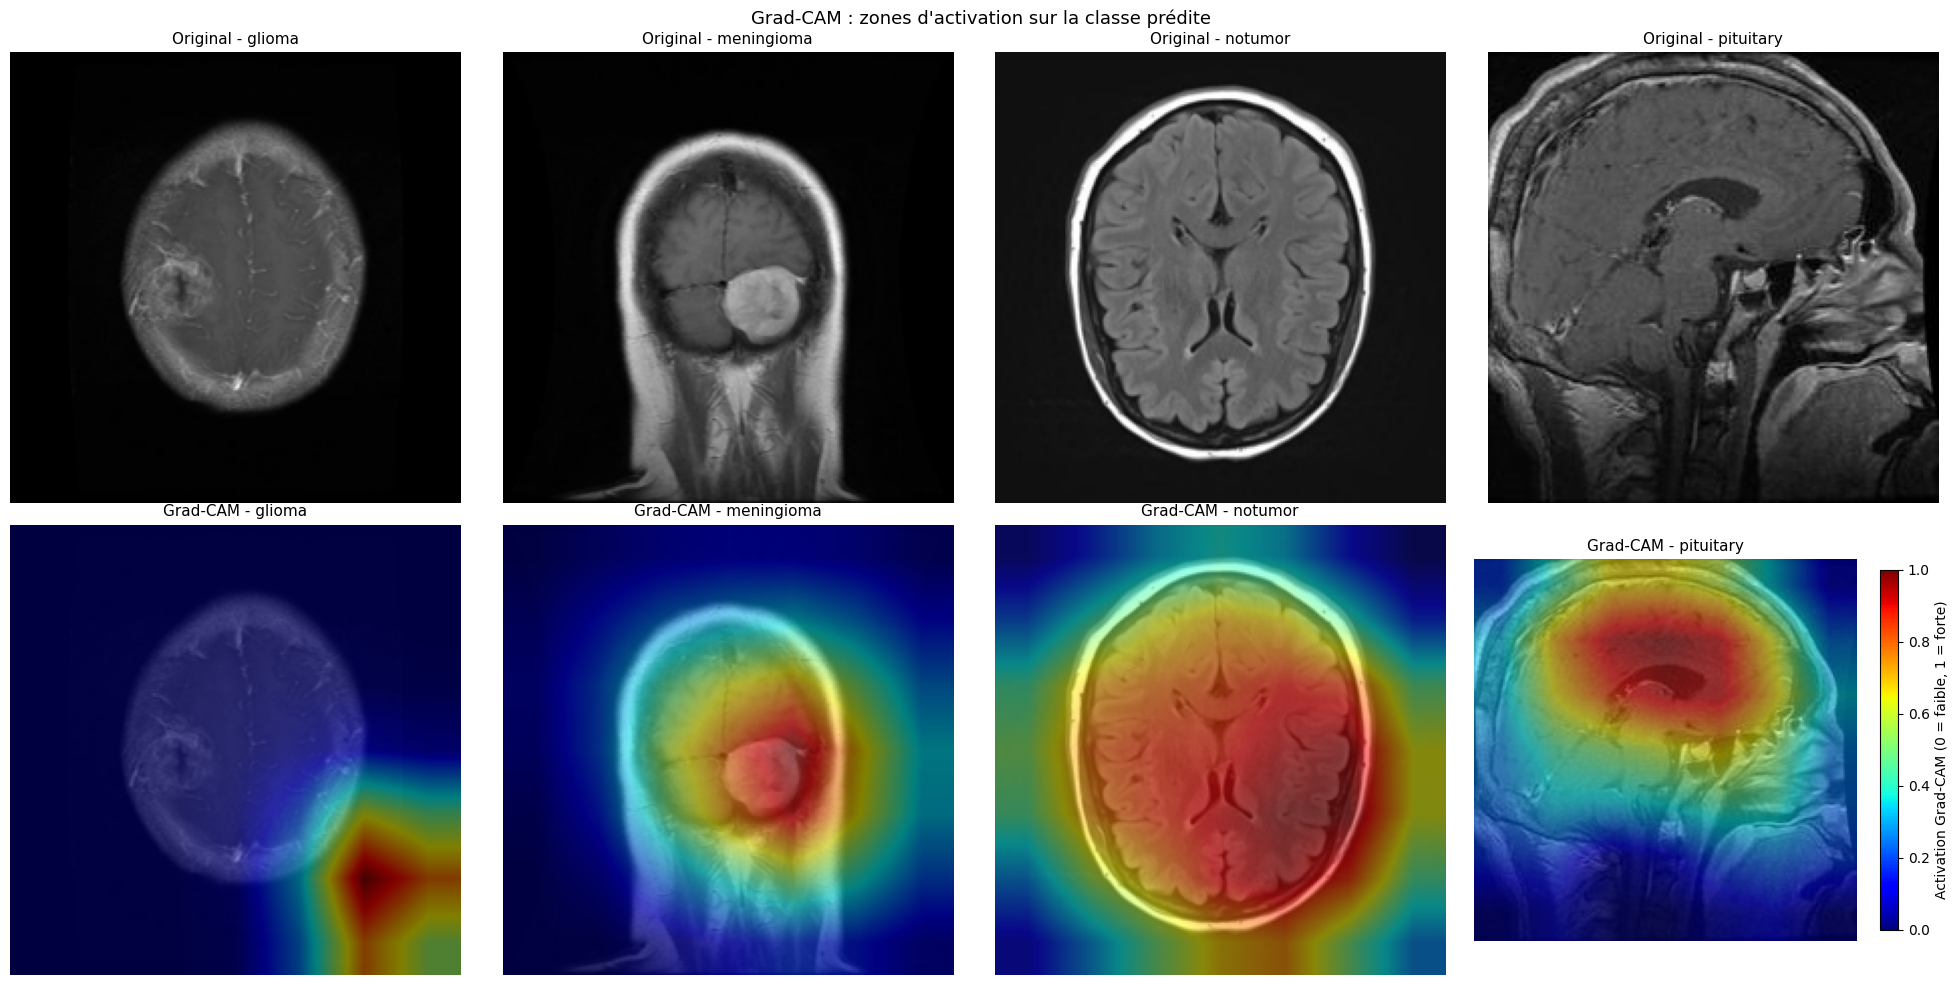

Sauvegardé gradcam_per_class.png


In [39]:
clinical_neutral = torch.tensor([0.5], dtype=torch.float32).to(device).unsqueeze(0)
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(20, 10))

for col, cls in enumerate(CLASSES):
    img_tensor = example_images[cls]
    true_idx   = CLASSES.index(cls)

    cam = gradcam.compute(img_tensor.clone(), clinical_neutral, true_idx)
    orig, overlay = overlay_cam(example_paths[cls], cam)

    axes[0, col].imshow(orig)
    axes[0, col].set_title(f"Original - {cls}", fontsize=11)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay)
    axes[1, col].set_title(f"Grad-CAM - {cls}", fontsize=11)
    axes[1, col].axis("off")

plt.suptitle("Grad-CAM : zones d'activation sur la classe prédite", fontsize=13)
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[1, -1], shrink=0.8, location="right", label="Activation Grad-CAM (0 = faible, 1 = forte)")
plt.tight_layout()
plt.savefig(f"{SAVEDIR}/gradcam_per_class.png", dpi=150)
plt.show()
print("Sauvegardé gradcam_per_class.png")

### 7. Résumé des figures produites

| Fichier | Contenu |
|---|---|
| `runs_gradcam/gradcam_per_class.png` | Grad-CAM BNN sur une image représentative par classe |
| `runs_gradcam/gradcam_cnn_vs_bnn.png` | Comparaison CNN baseline (ligne 2) vs BNN image only (ligne 3) |
| `runs_gradcam/gradcam_uncertainty.png` | Grad-CAM moyen + σ spatial sur 50 passes MC |

### 8. Comparaison Grad-CAM CNN baseline vs BNN image only

CNN baseline chargé — epoch 8, AUC=0.998


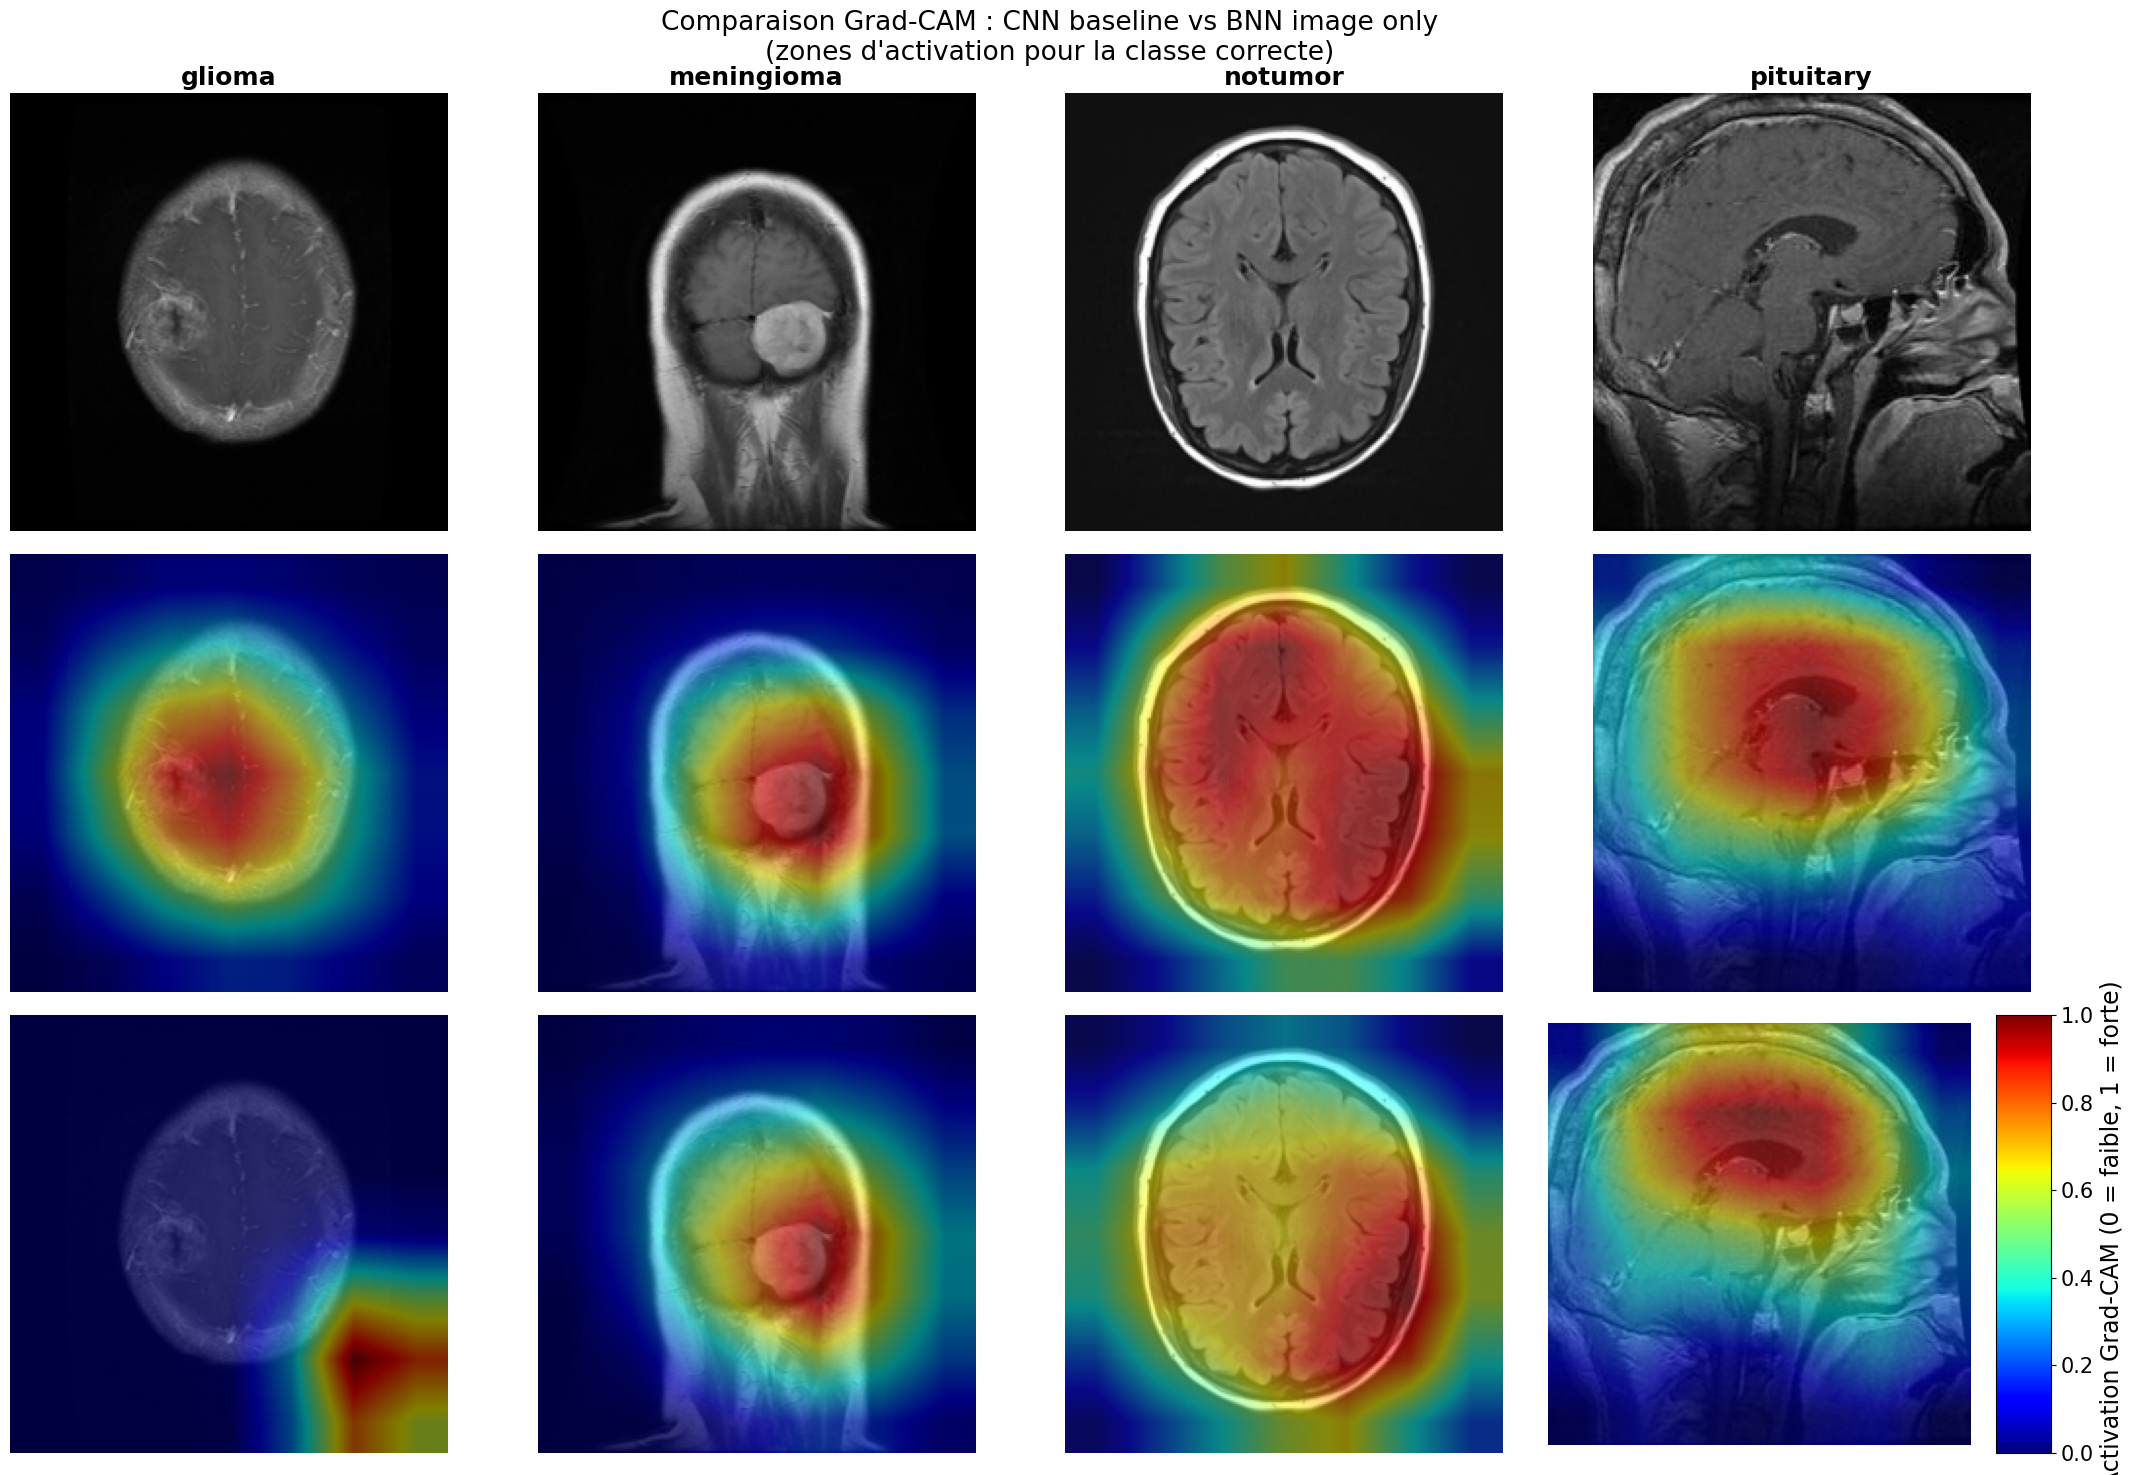

✓ Sauvegardé : gradcam_cnn_vs_bnn.png


In [40]:
CNN_CKPT = "runs_cnn_baseline/best_final.pt"

cnn_baseline = models.resnet18(weights="IMAGENET1K_V1")
cnn_baseline.fc = nn.Sequential(
    nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, NUM_CLASSES)
)
ckpt_cnn = torch.load(CNN_CKPT, map_location=device, weights_only=False)
cnn_baseline.load_state_dict(ckpt_cnn["model_state"])
cnn_baseline = cnn_baseline.to(device)
print(f"CNN baseline chargé — epoch {ckpt_cnn['epoch']}, AUC={ckpt_cnn['auc']:.3f}")

gradcam_cnn = GradCAM(cnn_baseline, cnn_baseline.layer4)

clinical_neutral = torch.tensor([[0.5]], dtype=torch.float32).to(device)

fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(22, 15))

for col, cls in enumerate(CLASSES):
    img_t    = example_images[cls]
    true_idx = CLASSES.index(cls)
    path     = example_paths[cls]

    cam_cnn = gradcam_cnn.compute(img_t.clone(), None, true_idx)
    cam_bnn = gradcam.compute(img_t.clone(), clinical_neutral, true_idx)

    orig, overlay_cnn = overlay_cam(path, cam_cnn)
    _,    overlay_bnn = overlay_cam(path, cam_bnn)

    axes[0, col].imshow(orig)
    axes[0, col].set_title(cls, fontsize=18, fontweight="bold")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Original", fontsize=18, rotation=90, labelpad=50)

    axes[1, col].imshow(overlay_cnn)
    axes[1, col].axis("off")
    if col == 0:
        axes[1, col].set_ylabel("CNN seul", fontsize=18, rotation=90, labelpad=50)

    axes[2, col].imshow(overlay_bnn)
    axes[2, col].axis("off")
    if col == 0:
        axes[2, col].set_ylabel("BNN image only", fontsize=18, rotation=90, labelpad=50)

plt.suptitle("Comparaison Grad-CAM : CNN baseline vs BNN image only\n"
             "(zones d'activation pour la classe correcte)", fontsize=19)
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[2, -1], shrink=1.0, aspect=8, location="right",
                    label="Activation Grad-CAM (0 = faible, 1 = forte)")
cbar.ax.yaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=15)
plt.tight_layout()
plt.savefig(f"{SAVEDIR}/gradcam_cnn_vs_bnn.png", dpi=150)
plt.show()
print("✓ Sauvegardé : gradcam_cnn_vs_bnn.png")

### 9. Incertitude sur l'attention, Grad-CAM moyen et écart-type (50 passes MC)

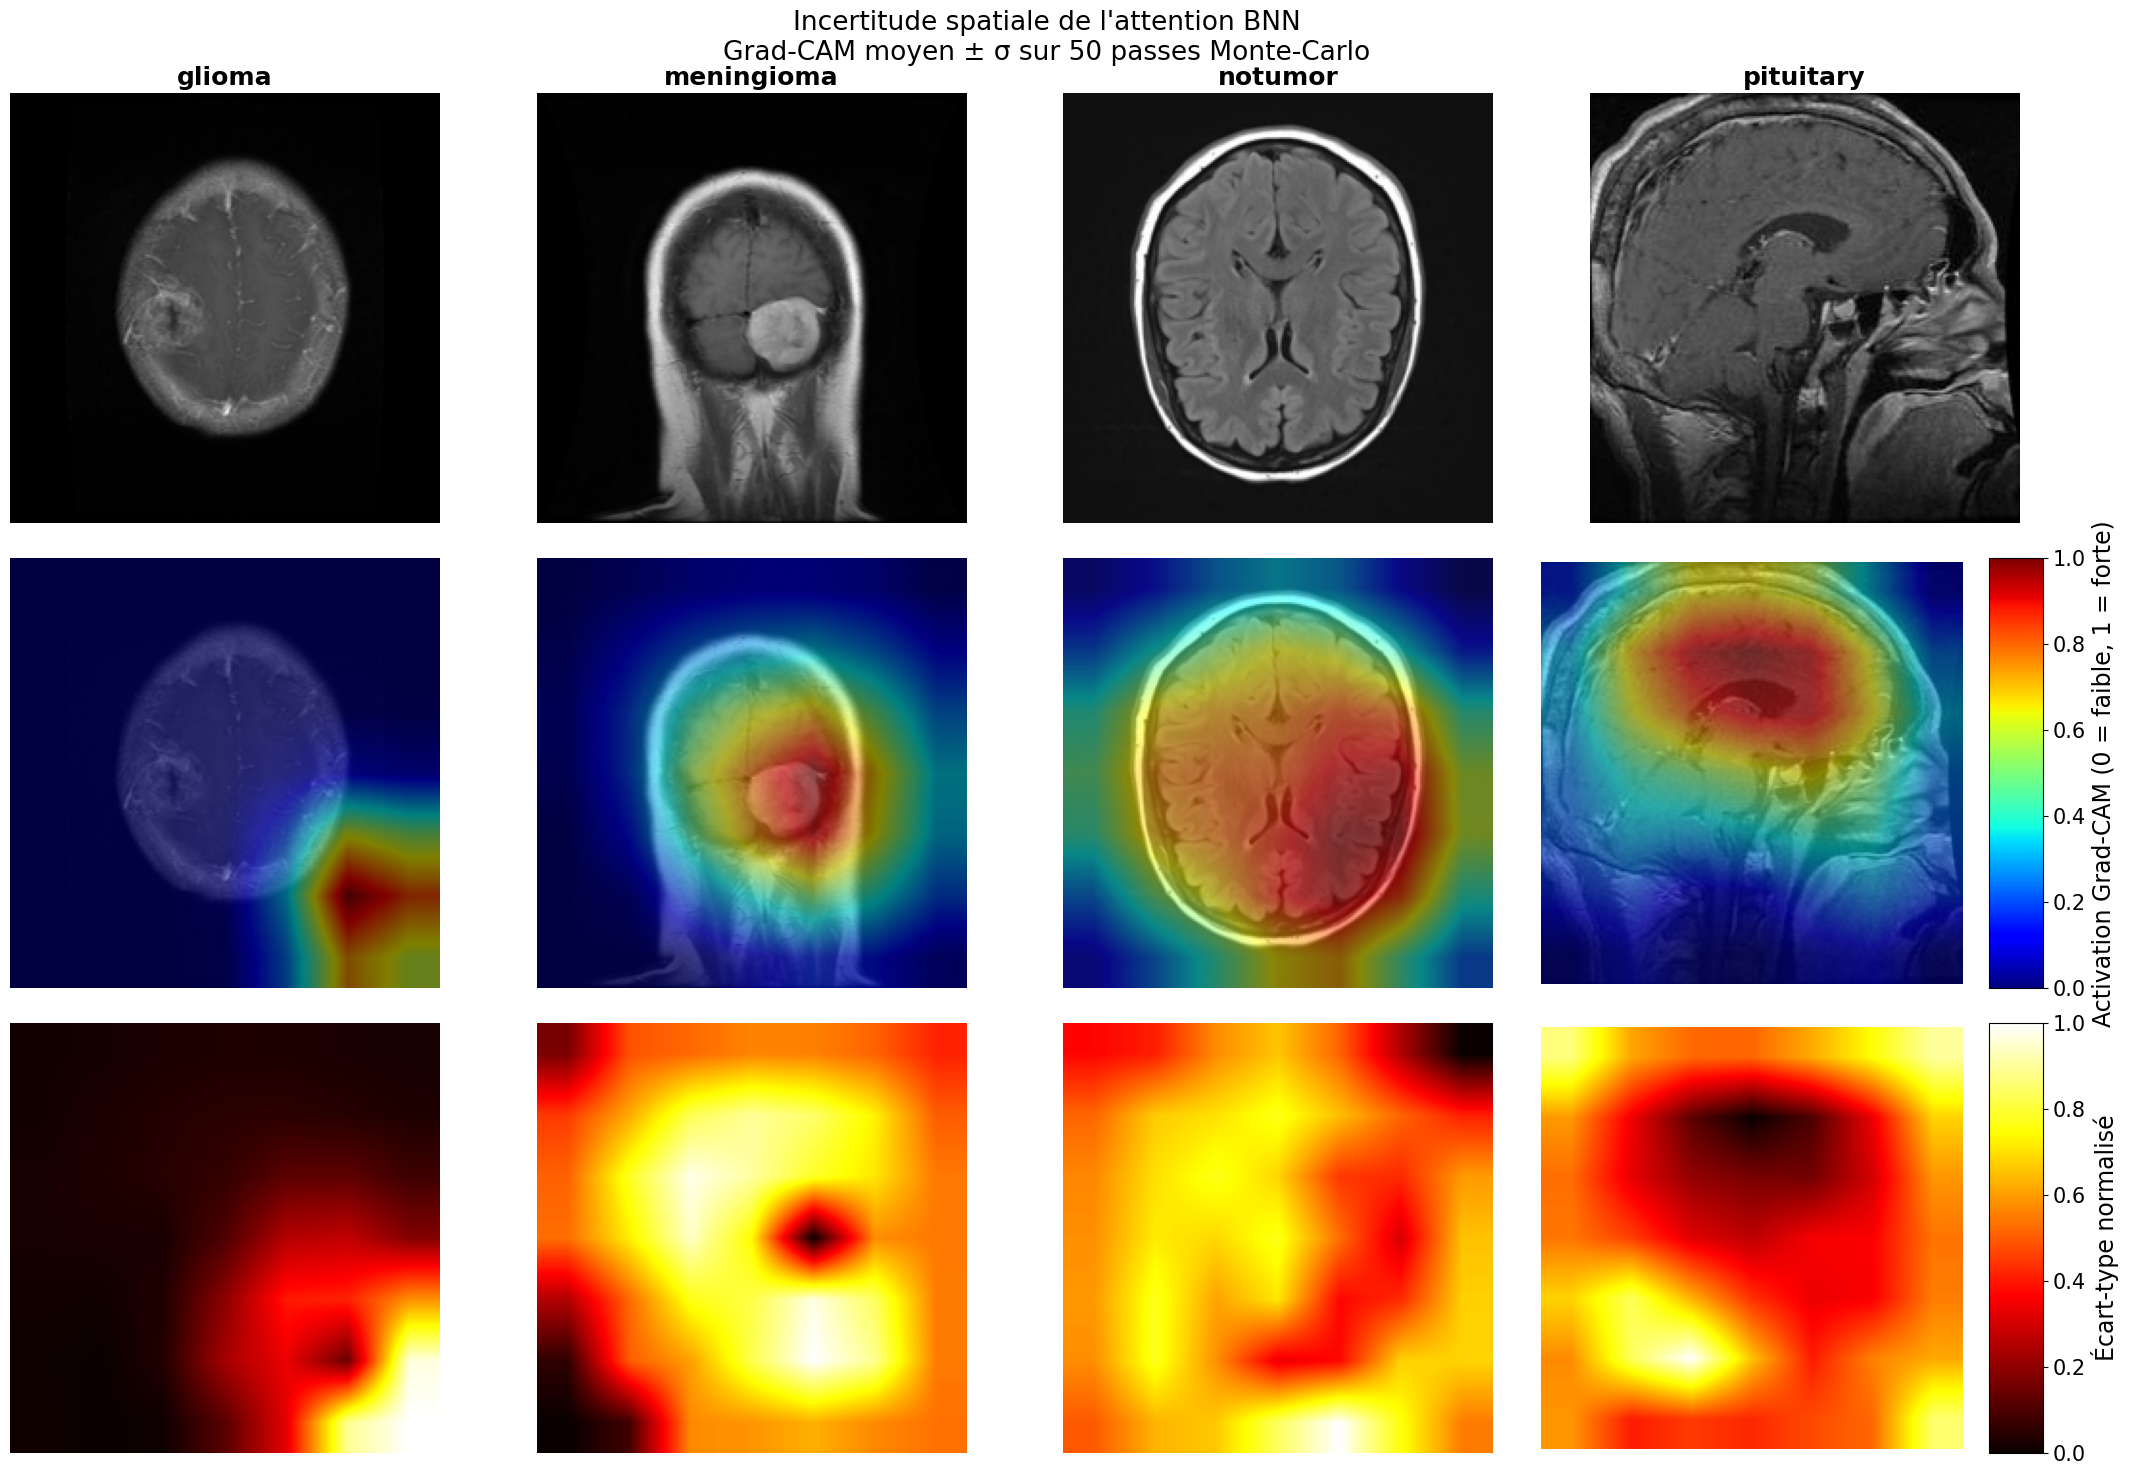

✓ Sauvegardé : gradcam_uncertainty.png


In [43]:
def compute_mc_gradcam(gradcam_obj, img_tensor, clinical_tensor, class_idx, n_passes=MC_PASSES):
    cams = []
    gradcam_obj.model.eval()
    for _ in range(n_passes):
        cam = gradcam_obj.compute(img_tensor.clone(), clinical_tensor, class_idx)
        cams.append(cam)
    cams = np.stack(cams, axis=0)
    return cams.mean(axis=0), cams.std(axis=0)


fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(22, 15))

for col, cls in enumerate(CLASSES):
    img_t    = example_images[cls]
    true_idx = CLASSES.index(cls)
    path     = example_paths[cls]

    mean_cam, std_cam = compute_mc_gradcam(
        gradcam, img_t, clinical_neutral, true_idx
    )
    orig, overlay_mean = overlay_cam(path, mean_cam)

    std_norm    = (std_cam - std_cam.min()) / (std_cam.max() - std_cam.min() + 1e-8)
    std_resized = cv2.resize(std_norm, (IMGSIZE, IMGSIZE))

    axes[0, col].imshow(orig)
    axes[0, col].set_title(cls, fontsize=18, fontweight="bold")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Original", fontsize=18, rotation=90, labelpad=50)

    axes[1, col].imshow(overlay_mean)
    axes[1, col].axis("off")
    if col == 0:
        axes[1, col].set_ylabel(f"CAM moyen\n({MC_PASSES} passes MC)", fontsize=18, rotation=90, labelpad=50)

    im = axes[2, col].imshow(std_resized, cmap="hot", vmin=0, vmax=1)
    axes[2, col].axis("off")
    if col == 0:
        axes[2, col].set_ylabel("Incertitude\nd'attention (σ)", fontsize=18, rotation=90, labelpad=50)

    axes[2, col].set_xlabel(f"σ moyen = {std_cam.mean():.4f}", fontsize=16)

cbar_sigma = fig.colorbar(im, ax=axes[2, -1], shrink=1.0, aspect=8,
                           location="right", label="Écart-type normalisé")
cbar_sigma.ax.yaxis.label.set_size(17)
cbar_sigma.ax.tick_params(labelsize=15)

plt.suptitle(f"Incertitude spatiale de l'attention BNN\n"
             f"Grad-CAM moyen ± σ sur {MC_PASSES} passes Monte-Carlo", fontsize=19)
norm = mcolors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
cbar_cam = fig.colorbar(sm, ax=axes[1, -1], shrink=1.0, aspect=8,
                         location="right", label="Activation Grad-CAM (0 = faible, 1 = forte)")
cbar_cam.ax.yaxis.label.set_size(17)
cbar_cam.ax.tick_params(labelsize=15)
plt.tight_layout()
plt.savefig(f"{SAVEDIR}/gradcam_uncertainty.png", dpi=150)
plt.show()
print("✓ Sauvegardé : gradcam_uncertainty.png")

In [42]:
print("=" * 50)
print(f"Figures sauvegardées dans : {SAVEDIR}")
print("=" * 50)
figures = {
    "gradcam_per_class.png":   "Grad-CAM BNN — zones activées par classe",
    "gradcam_cnn_vs_bnn.png":  "Comparaison Grad-CAM : CNN baseline vs BNN",
    "gradcam_uncertainty.png": "Incertitude spatiale d'attention (σ sur 50 passes MC)",
}
for fname, desc in figures.items():
    path   = os.path.join(SAVEDIR, fname)
    exists = "✓" if os.path.exists(path) else "✗"
    print(f"  {exists}  {fname:<35} {desc}")

Figures sauvegardées dans : runs_gradcam
  ✓  gradcam_per_class.png               Grad-CAM BNN — zones activées par classe
  ✓  gradcam_cnn_vs_bnn.png              Comparaison Grad-CAM : CNN baseline vs BNN
  ✓  gradcam_uncertainty.png             Incertitude spatiale d'attention (σ sur 50 passes MC)
